# **Modelling Data (Klasifikasi Time Series - Dataset BME)**

In [12]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib

df_train = pd.read_csv('BME_TRAIN.csv')
df_test = pd.read_csv('BME_TEST.csv')

X_train = df_train. drop('target', axis=1)
y_train = df_train['target']
X_test = df_test.drop('target', axis=1)
y_test = df_test['target']

scaler = joblib.load('scaler_bme.pkl')

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled. shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (30, 128)
X_test_scaled shape: (8, 128)


### 4.1 Baseline Model SVM Linear

In [13]:
svm_baseline = SVC(kernel='linear', random_state=42)
svm_baseline. fit(X_train_scaled, y_train)

y_pred_baseline = svm_baseline. predict(X_test_scaled)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Akurasi Baseline Model: {acc_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Akurasi Baseline Model: 0.8750

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       1.00      0.50      0.67         2

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.84         8
weighted avg       0.91      0.88      0.86         8



### 4.2 Hyperparameter Tuning dengan GridSearchCV

In [14]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['linear']
}

print("Parameter yang akan dituning:")
print(f"C: {param_grid['C']}")

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("\n--- Hasil GridSearchCV ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search. best_score_:.4f}")

Parameter yang akan dituning:
C: [0.001, 0.01, 0.1, 1, 10, 100]
Fitting 5 folds for each of 6 candidates, totalling 30 fits

--- Hasil GridSearchCV ---
Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.9667


In [15]:
print("\n--- Detail Hasil GridSearchCV ---")
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_display = cv_results[['param_C', 'mean_test_score', 'std_test_score', 'rank_test_score']]
cv_results_display = cv_results_display.sort_values('rank_test_score')
print(cv_results_display. to_string(index=False))


--- Detail Hasil GridSearchCV ---
param_C  mean_test_score  std_test_score  rank_test_score
    0.1         0.966667        0.066667                1
      1         0.966667        0.066667                1
     10         0.966667        0.066667                1
    100         0.966667        0.066667                1
   0.01         0.833333        0.149071                5
  0.001         0.766667        0.200000                6


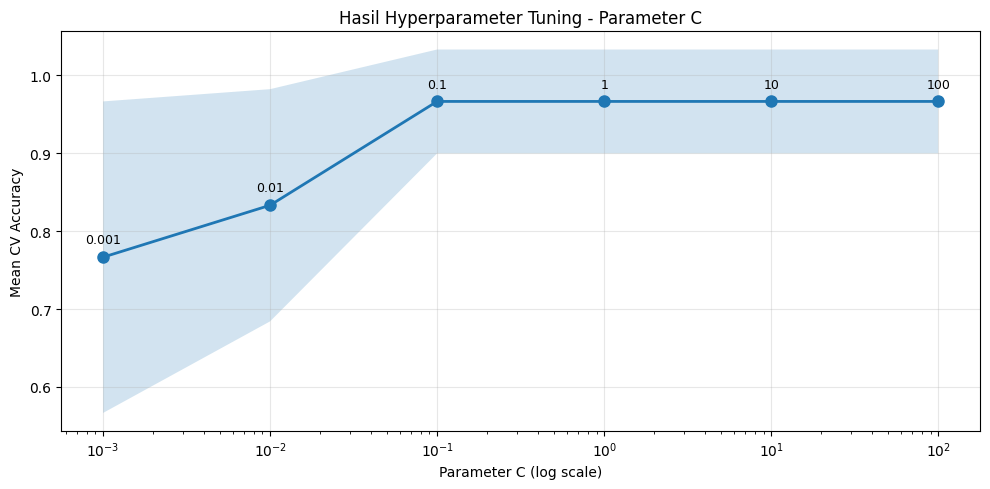

In [16]:
# Visualisasi hasil tuning
plt.figure(figsize=(10, 5))
plt.plot(param_grid['C'], cv_results['mean_test_score'], marker='o', linewidth=2, markersize=8)
plt.fill_between(param_grid['C'], 
                 cv_results['mean_test_score'] - cv_results['std_test_score'],
                 cv_results['mean_test_score'] + cv_results['std_test_score'],
                 alpha=0.2)
plt.xscale('log')

for i, c_val in enumerate(param_grid['C']):
    plt.annotate(f'{c_val}', 
                xy=(c_val, cv_results['mean_test_score'][i]),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.xlabel('Parameter C (log scale)')
plt.ylabel('Mean CV Accuracy')
plt.title('Hasil Hyperparameter Tuning - Parameter C')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Model Final dengan Best Parameters

In [17]:
best_model = grid_search.best_estimator_
print(f"Model Final: SVC(kernel='linear', C={grid_search.best_params_['C']})")

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

y_pred_final = best_model.predict(X_test_scaled)
acc_final = accuracy_score(y_test, y_pred_final)

print("\n" + "=" * 60)
print("MODEL FINAL - EVALUASI PADA TEST SET")
print("=" * 60)
print(f"Akurasi Test Set: {acc_final:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

joblib.dump(best_model, 'model_svm_bme.pkl')

Model Final: SVC(kernel='linear', C=0.1)

Cross-Validation Scores: [1.         1.         0.83333333 1.         1.        ]
Mean CV Score: 0.9667 (+/- 0.1333)

MODEL FINAL - EVALUASI PADA TEST SET
Akurasi Test Set: 0.8750

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       1.00      0.50      0.67         2

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.84         8
weighted avg       0.91      0.88      0.86         8



['model_svm_bme.pkl']